CSV TO DATAFRAME

In [2]:
import pandas as pd

df = pd.read_csv("data/priceRelatedFeatures.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

           category                                              title  \
0  wireless earbuds  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...   
1  wireless earbuds  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...   
2  wireless earbuds  XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 ...   
3  wireless earbuds  Wireless Earbuds Bluetooth Headphones, 54H Pla...   
4  wireless earbuds  HAOYUYAN Wireless Earbuds, Sports Bluetooth He...   

      brand  rating ratingCount  \
0    Fhumsh     4.8       (350)   
1    Fhumsh     4.8       (350)   
2  XIAOWTEK     4.9       (673)   
3    TRAUSI     4.8       (220)   
4  HAOYUYAN     4.9       (234)   

                                         description  \
0  About this itemSmart LED Display & 50H Sport H...   
1  About this itemErgonomic Wireless Earbuds for ...   
2  About this itemLED Power Display and 50H Playb...   
3  About this item【Instant Pairing & Seamless Con...   
4  About this item【Sports Comfort & IPX7 Waterpro...   

       

Data Preprocessing

In [3]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)

category         0
title            0
brand          161
rating           3
ratingCount      3
description    144
price          124
dtype: int64
category        0.000000
title           0.000000
brand          19.350962
rating          0.360577
ratingCount     0.360577
description    17.307692
price          14.903846
dtype: float64


In [4]:
df = df.dropna(subset=["price"])

print(df.isnull().sum())

category         0
title            0
brand          147
rating           2
ratingCount      2
description    132
price            0
dtype: int64


In [5]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 47


In [6]:
print(
    "Duplicate products:",
    df.duplicated(
        subset=["title", "brand"]
    ).sum()
)

Duplicate products: 83


In [7]:
duplicates = df[
    df.duplicated(
        subset=["title", "brand"],
        keep=False
    )
].sort_values(["title", "brand"])

print(duplicates[
    ["title", "brand", "category", "price", "ratingCount"]
].head(30))

                                                 title              brand  \
587  "Moleskine Classic Notebook, Soft Cover, Large...                NaN   
591  "Moleskine Classic Notebook, Soft Cover, Large...                NaN   
780  3 in 1 Mag-Safe Wireless Charger Stand for iPh...             Ouotoo   
781  3 in 1 Mag-Safe Wireless Charger Stand for iPh...             Ouotoo   
826  40/41/42" Acoustic Guitar Bag,Oxford Fabric wi...                NaN   
827  40/41/42" Acoustic Guitar Bag,Oxford Fabric wi...                NaN   
593  A5 Lined Notebook 5.9"x8.4", Hardcover Leather...            vfaejll   
598  A5 Lined Notebook 5.9"x8.4", Hardcover Leather...            vfaejll   
474  AOC 27 Inch Computer Monitor FHD 120Hz Fast IP...                AOC   
475  AOC 27 Inch Computer Monitor FHD 120Hz Fast IP...                AOC   
473  AOC 27" Gaming Monitor QHD 260Hz Overclocked I...                AOC   
478  AOC 27" Gaming Monitor QHD 260Hz Overclocked I...                AOC   

In [8]:
df.drop_duplicates(inplace=True)

In [9]:


print("Shape after removing exact duplicates:", df.shape)
print("Remaining exact duplicates:", df.duplicated().sum())

Shape after removing exact duplicates: (661, 7)
Remaining exact duplicates: 0


In [10]:
df["price"] = (
    df["price"]
    .str.extract(r"\$([\d,]+(?:\.\d+)?)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [11]:
print(df["price"].head(20))
print(df["price"].dtype)

0      19.97
1      19.97
2      19.99
3      20.99
4      23.98
5      36.52
7      19.99
8      13.99
9      16.99
10     47.99
11      9.99
12     26.55
14    249.99
15     16.99
16     34.98
17    179.95
18     14.97
19     48.99
20     16.99
21     19.99
Name: price, dtype: float64
float64


In [12]:
print("Missing prices:", df["price"].isna().sum())

Missing prices: 0


In [13]:
print(df["price"].describe())

count     661.000000
mean       71.598185
std       110.600799
min         2.790000
25%        16.990000
50%        29.990000
75%        79.990000
max      1145.000000
Name: price, dtype: float64


In [14]:
print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())
print("Median price:", df["price"].median())

Minimum price: 2.79
Maximum price: 1145.0
Median price: 29.99


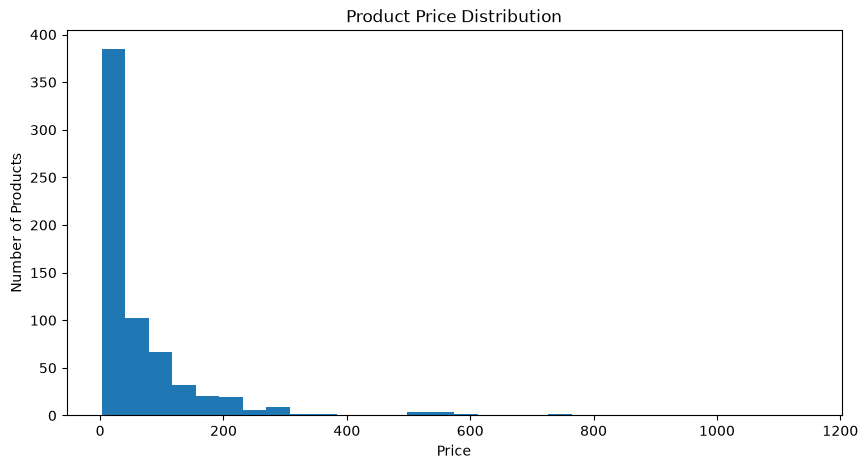

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=30)

plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.title("Product Price Distribution")

plt.show()

In [16]:
print(df.columns.tolist())

['category', 'title', 'brand', 'rating', 'ratingCount', 'description', 'price']


In [17]:
print("Duplicate titles:", df.duplicated(subset=["title"]).sum())

Duplicate titles: 46


In [18]:
print(df["price"].describe())

count     661.000000
mean       71.598185
std       110.600799
min         2.790000
25%        16.990000
50%        29.990000
75%        79.990000
max      1145.000000
Name: price, dtype: float64


In [19]:
print(df["category"].value_counts())

category
desk lamp LED              47
sneakers                   44
sunglasses                 43
notebook journal           42
t-shirt                    40
candle                     39
kitchen knife set          38
water bottle               37
yamaha accoustic guitar    35
electric toothbrush        33
gaming chair               30
coffee maker               29
mechanical keyboard        16
smartwatch                 16
webcam HD                  16
instant pot                16
gaming mouse               15
phone case                 15
wireless earbuds           14
USB-C hub                  13
backpack                   13
phone stand                13
monitor 27 inch            12
portable charger           11
bluetooth speaker          11
DSLR camera                10
budget laptop               9
air purifier                4
Name: count, dtype: int64


In [20]:
category_price_stats = df.groupby("category")["price"].agg(
    ["count", "min", "median", "max"]
).sort_values("count", ascending=False)

print(category_price_stats)

                         count    min   median      max
category                                               
desk lamp LED               47   9.99   25.490    79.99
sneakers                    44  19.90   52.875    90.00
sunglasses                  43   6.99   15.990   229.00
notebook journal            42   2.79   10.990    36.99
t-shirt                     40   5.99   12.670    36.99
candle                      39   9.99   19.990   119.98
kitchen knife set           38  19.98   79.980  1145.00
water bottle                37   8.99   24.000    50.00
yamaha accoustic guitar     35   5.99   72.990   599.99
electric toothbrush         33   7.99   48.590   379.96
gaming chair                30  25.99  132.480   408.84
coffee maker                29  21.99   74.950   555.95
instant pot                 16  67.94  109.990   219.99
smartwatch                  16  13.99   71.990   799.99
webcam HD                   16  18.99   58.180   199.59
mechanical keyboard         16  15.99   61.490  

In [21]:
category_counts = df["category"].value_counts()

eligible_categories = category_counts[category_counts >= 20]
small_categories = category_counts[category_counts < 20]

print("Eligible categories:", len(eligible_categories))
print("Products in eligible categories:", eligible_categories.sum())

print("\nSmall categories:")
print(small_categories)

print("\nProducts in small categories:", small_categories.sum())

Eligible categories: 12
Products in eligible categories: 457

Small categories:
category
mechanical keyboard    16
smartwatch             16
webcam HD              16
instant pot            16
gaming mouse           15
phone case             15
wireless earbuds       14
USB-C hub              13
backpack               13
phone stand            13
monitor 27 inch        12
portable charger       11
bluetooth speaker      11
DSLR camera            10
budget laptop           9
air purifier            4
Name: count, dtype: int64

Products in small categories: 204


In [22]:
print(sorted(df["category"].unique()))

['DSLR camera', 'USB-C hub', 'air purifier', 'backpack', 'bluetooth speaker', 'budget laptop', 'candle', 'coffee maker', 'desk lamp LED', 'electric toothbrush', 'gaming chair', 'gaming mouse', 'instant pot', 'kitchen knife set', 'mechanical keyboard', 'monitor 27 inch', 'notebook journal', 'phone case', 'phone stand', 'portable charger', 'smartwatch', 'sneakers', 'sunglasses', 't-shirt', 'water bottle', 'webcam HD', 'wireless earbuds', 'yamaha accoustic guitar']


In [23]:
category_quantiles = df.groupby("category")["price"].quantile([0.33, 0.67]).unstack()

category_quantiles.columns = ["q33", "q67"]

print(category_quantiles)

                              q33       q67
category                                   
DSLR camera              244.2400  499.9000
USB-C hub                 17.9116   31.8288
air purifier              79.4150  103.7600
backpack                  26.9900   35.0904
bluetooth speaker         26.4900   68.9120
budget laptop            227.5420  290.9500
candle                    18.0386   23.4636
coffee maker              52.7176   89.9900
desk lamp LED             19.9900   29.9900
electric toothbrush       24.2212   96.5236
gaming chair              99.9900  149.9900
gaming mouse              29.6100   52.0338
instant pot               89.9880  150.9900
kitchen knife set         74.1916  106.8820
mechanical keyboard       48.9900   69.9900
monitor 27 inch           99.9900  137.3900
notebook journal           7.4405   14.9847
phone case                 9.9900   20.4114
phone stand                9.9900   19.9900
portable charger           9.9900   15.7190
smartwatch                29.690

In [24]:
def assign_tier(group):
    q33 = group["price"].quantile(0.33)
    q67 = group["price"].quantile(0.67)

    return pd.cut(
        group["price"],
        bins=[-float("inf"), q33, q67, float("inf")],
        labels=["Budget", "Mid-range", "Premium"],
        include_lowest=True
    )

df["price_tier_temp"] = df.groupby(
    "category",
    group_keys=False
).apply(assign_tier, include_groups=False).reset_index(level=0, drop=True)

print(
    df.groupby(["category", "price_tier_temp"], observed=False)
      .size()
      .unstack(fill_value=0)
)

price_tier_temp          Budget  Mid-range  Premium
category                                           
DSLR camera                   3          4        3
USB-C hub                     7          3        3
air purifier                  3          1        0
backpack                      5          3        5
bluetooth speaker             3          5        3
budget laptop                 5          1        3
candle                        0          0        0
coffee maker                 12          7       10
desk lamp LED                17         15       15
electric toothbrush          12         12        9
gaming chair                  8         11       11
gaming mouse                  3          7        5
instant pot                   3          6        7
kitchen knife set            14         13       11
mechanical keyboard           4          5        7
monitor 27 inch               7          4        1
notebook journal             15         15       12
phone case  

In [25]:
print(
    df[df["category"] == "candle"]["price"]
    .sort_values()
    .to_list()
)

[9.99, 11.99, 12.99, 15.75, 15.99, 16.5, 16.56, 16.99, 16.99, 16.99, 17.95, 17.99, 17.99, 18.08, 18.99, 19.79, 19.97, 19.97, 19.97, 19.99, 19.99, 21.44, 21.49, 21.95, 22.39, 23.39, 23.55, 24.95, 25.99, 25.99, 31.99, 34.98, 35.4, 37.79, 42.95, 55.0, 55.95, 89.0, 119.98]


In [26]:
def assign_tier_by_rank(group):
    ranks = group["price"].rank(method="first")

    return pd.qcut(
        ranks,
        q=3,
        labels=["Budget", "Mid-range", "Premium"]
    )

df["price_tier_temp"] = (
    df.groupby("category", group_keys=False)
      .apply(assign_tier_by_rank, include_groups=False)
      .reset_index(level=0, drop=True)
)

print(
    df.groupby(["category", "price_tier_temp"], observed=False)
      .size()
      .unstack(fill_value=0)
)

price_tier_temp          Budget  Mid-range  Premium
category                                           
DSLR camera                   3          4        3
USB-C hub                     7          3        3
air purifier                  3          1        0
backpack                      5          3        5
bluetooth speaker             3          5        3
budget laptop                 5          1        3
candle                        0          0        0
coffee maker                 10          8       11
desk lamp LED                16         15       16
electric toothbrush          12         11       10
gaming chair                  8         11       11
gaming mouse                  5          5        5
instant pot                   3          6        7
kitchen knife set            14         12       12
mechanical keyboard           4          5        7
monitor 27 inch               7          4        1
notebook journal             16         13       13
phone case  

In [27]:
print(
    df[df["category"] == "candle"]
    [["title", "price", "price_tier_temp"]]
    .sort_values("price")
    .to_string(index=False)
)

                                                                                                                                                                                                   title  price price_tier_temp
                                                                                                                                                  Molensun Lemon Eucalyptus Scented Candle, Soy Wax 7 oz   9.99             NaN
                                                                                                                                      Scented Candles, Lavender Eucalyptus Candles, Non Toxic Soy Candle  11.99             NaN
                                 AOOVOO Lavender Scented Candles for Women - Aromatherapy Candle with Crystals Inside, 7oz Soy Candles for Home Scented, Birthday Gifts Mothers Day Candle for Women Mom  12.99             NaN
                            Vanilla Bean Odor Eliminating Highly Fragranced Candle - Eliminates 95% of P

In [28]:
df["price_rank"] = (
    df.groupby("category")["price"]
      .rank(method="first")
)

df["price_tier_temp"] = (
    df.groupby("category")["price_rank"]
      .transform(
          lambda x: pd.qcut(
              x,
              q=3,
              labels=["Budget", "Mid-range", "Premium"]
          )
      )
)

In [29]:
print(
    df[df["category"] == "candle"]
    [["title", "price", "price_rank", "price_tier_temp"]]
    .sort_values("price")
    .to_string(index=False)
)

                                                                                                                                                                                                   title  price  price_rank price_tier_temp
                                                                                                                                                  Molensun Lemon Eucalyptus Scented Candle, Soy Wax 7 oz   9.99         1.0          Budget
                                                                                                                                      Scented Candles, Lavender Eucalyptus Candles, Non Toxic Soy Candle  11.99         2.0          Budget
                                 AOOVOO Lavender Scented Candles for Women - Aromatherapy Candle with Crystals Inside, 7oz Soy Candles for Home Scented, Birthday Gifts Mothers Day Candle for Women Mom  12.99         3.0          Budget
                            Vanilla Bean Odor Eliminatin

In [30]:
price_tier_check = (
    df.groupby(["category", "price"])["price_tier_temp"]
      .nunique()
      .reset_index(name="tier_count")
)

print(
    price_tier_check[price_tier_check["tier_count"] > 1]
)

                category   price  tier_count
104         coffee maker   89.99           2
120        desk lamp LED   19.99           2
133        desk lamp LED   29.99           2
182         gaming chair   99.99           2
188         gaming chair  149.99           2
265  mechanical keyboard   69.99           2
273      monitor 27 inch   99.99           2
314           phone case    9.99           2
324          phone stand    9.99           2
327          phone stand   19.99           2
332     portable charger    9.99           2
398           sunglasses   13.99           2
403           sunglasses   16.99           2
434              t-shirt   14.99           2
486            webcam HD   69.99           2
494     wireless earbuds   19.97           2


In [31]:
unique_price_counts = df.groupby("category")["price"].nunique().sort_values()

print(unique_price_counts)

category
air purifier                4
phone stand                 6
monitor 27 inch             9
budget laptop               9
DSLR camera                10
backpack                   10
portable charger           10
bluetooth speaker          11
wireless earbuds           11
phone case                 12
instant pot                13
USB-C hub                  13
mechanical keyboard        14
webcam HD                  14
gaming mouse               15
smartwatch                 16
sunglasses                 22
gaming chair               22
coffee maker               24
electric toothbrush        28
yamaha accoustic guitar    29
water bottle               31
kitchen knife set          31
candle                     32
t-shirt                    32
notebook journal           32
desk lamp LED              34
sneakers                   37
Name: price, dtype: int64


In [32]:
def assign_price_tiers(group):
    # Get unique prices within this category
    unique_prices = group["price"].drop_duplicates()

    # Calculate quantile boundaries using unique prices
    q33 = unique_prices.quantile(0.33)
    q67 = unique_prices.quantile(0.67)

    # Assign tiers using the actual price
    return pd.cut(
        group["price"],
        bins=[-float("inf"), q33, q67, float("inf")],
        labels=["Budget", "Mid-range", "Premium"],
        include_lowest=True
    )


df["price_tier"] = (
    df.groupby("category", group_keys=False)
      .apply(assign_price_tiers, include_groups=False)
      .reset_index(level=0, drop=True)
)

In [33]:
print(
    df.groupby(["category", "price_tier"], observed=False)
      .size()
      .unstack(fill_value=0)
)

price_tier               Budget  Mid-range  Premium
category                                           
DSLR camera                   3          4        3
USB-C hub                     7          3        3
air purifier                  3          1        0
backpack                      5          3        5
bluetooth speaker             3          5        3
budget laptop                 5          1        3
candle                        0          0        0
coffee maker                 13          5       11
desk lamp LED                20         14       13
electric toothbrush          10         15        8
gaming chair                  7         13       10
gaming mouse                  3          7        5
instant pot                   2          6        8
kitchen knife set            13         11       14
mechanical keyboard           4          6        6
monitor 27 inch               7          4        1
notebook journal             16         14       12
phone case  

In [37]:
df.drop(
    columns=["price_rank", "price_tier_temp", "price_tier"],
    errors="ignore",
    inplace=True
)

In [35]:
df["price_percentile"] = (
    df.groupby("category")["price"]
      .rank(pct=True, method="average")
)

print(
    df[df["category"] == "candle"]
    [["price", "price_percentile"]]
    .sort_values("price")
    .to_string(index=False)
)

 price  price_percentile
  9.99          0.025641
 11.99          0.051282
 12.99          0.076923
 15.75          0.102564
 15.99          0.128205
 16.50          0.153846
 16.56          0.179487
 16.99          0.230769
 16.99          0.230769
 16.99          0.230769
 17.95          0.282051
 17.99          0.320513
 17.99          0.320513
 18.08          0.358974
 18.99          0.384615
 19.79          0.410256
 19.97          0.461538
 19.97          0.461538
 19.97          0.461538
 19.99          0.525641
 19.99          0.525641
 21.44          0.564103
 21.49          0.589744
 21.95          0.615385
 22.39          0.641026
 23.39          0.666667
 23.55          0.692308
 24.95          0.717949
 25.99          0.756410
 25.99          0.756410
 31.99          0.794872
 34.98          0.820513
 35.40          0.846154
 37.79          0.871795
 42.95          0.897436
 55.00          0.923077
 55.95          0.948718
 89.00          0.974359
119.98          1.000000


In [38]:
df["price_tier"] = pd.cut(
    df["price_percentile"],
    bins=[0, 0.33, 0.67, 1.0],
    labels=["Budget", "Mid-range", "Premium"],
    include_lowest=True
)

In [39]:
print(
    df.groupby(["category", "price_tier"], observed=False)
      .size()
      .unstack(fill_value=0)
)

price_tier               Budget  Mid-range  Premium
category                                           
DSLR camera                   3          3        4
USB-C hub                     4          4        5
air purifier                  1          1        2
backpack                      3          5        5
bluetooth speaker             3          4        4
budget laptop                 2          4        3
candle                       13         13       13
coffee maker                  9         11        9
desk lamp LED                17         13       17
electric toothbrush          10         12       11
gaming chair                  9         13        8
gaming mouse                  4          6        5
instant pot                   5          5        6
kitchen knife set            12         13       13
mechanical keyboard           5          5        6
monitor 27 inch               3          5        4
notebook journal             14         14       14
phone case  

In [40]:
print(df["price_tier"].value_counts())

print("\nPercentage:")
print(
    df["price_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

price_tier
Premium      229
Mid-range    228
Budget       204
Name: count, dtype: int64

Percentage:
price_tier
Premium      34.64
Mid-range    34.49
Budget       30.86
Name: proportion, dtype: float64


In [43]:
df["ratingCount"] = (
    df["ratingCount"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 661 entries, 0 to 831
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   category          661 non-null    str     
 1   title             661 non-null    str     
 2   brand             520 non-null    str     
 3   rating            661 non-null    float64 
 4   ratingCount       659 non-null    float64 
 5   description       536 non-null    str     
 6   price             661 non-null    float64 
 7   price_percentile  661 non-null    float64 
 8   price_tier        661 non-null    category
dtypes: category(1), float64(4), str(4)
memory usage: 47.1 KB


In [45]:
df["rating"] = df["rating"].fillna(df["rating"].median())
df["ratingCount"] = df["ratingCount"].fillna(df["ratingCount"].median())

In [46]:
df["description"] = df["description"].fillna("")

In [47]:
print(df[[
    "title",
    "brand",
    "description",
    "rating",
    "ratingCount",
    "category",
    "price_tier"
]].isnull().sum())

title            0
brand          141
description      0
rating           0
ratingCount      0
category         0
price_tier       0
dtype: int64


In [48]:
print(df.isnull().sum())

category              0
title                 0
brand               141
rating                0
ratingCount           0
description           0
price                 0
price_percentile      0
price_tier            0
dtype: int64


EDA

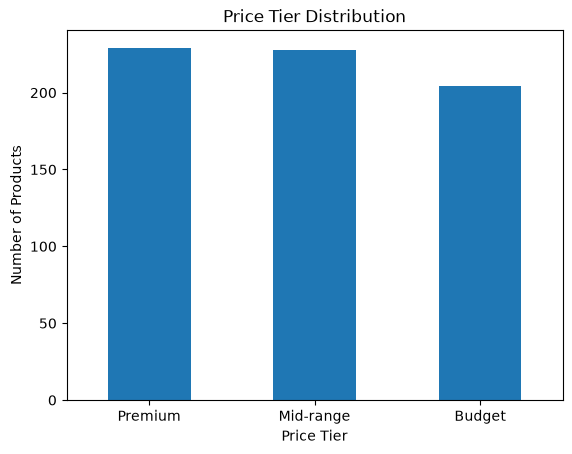

In [49]:
import matplotlib.pyplot as plt

df["price_tier"].value_counts().plot(kind="bar")

plt.title("Price Tier Distribution")
plt.xlabel("Price Tier")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()

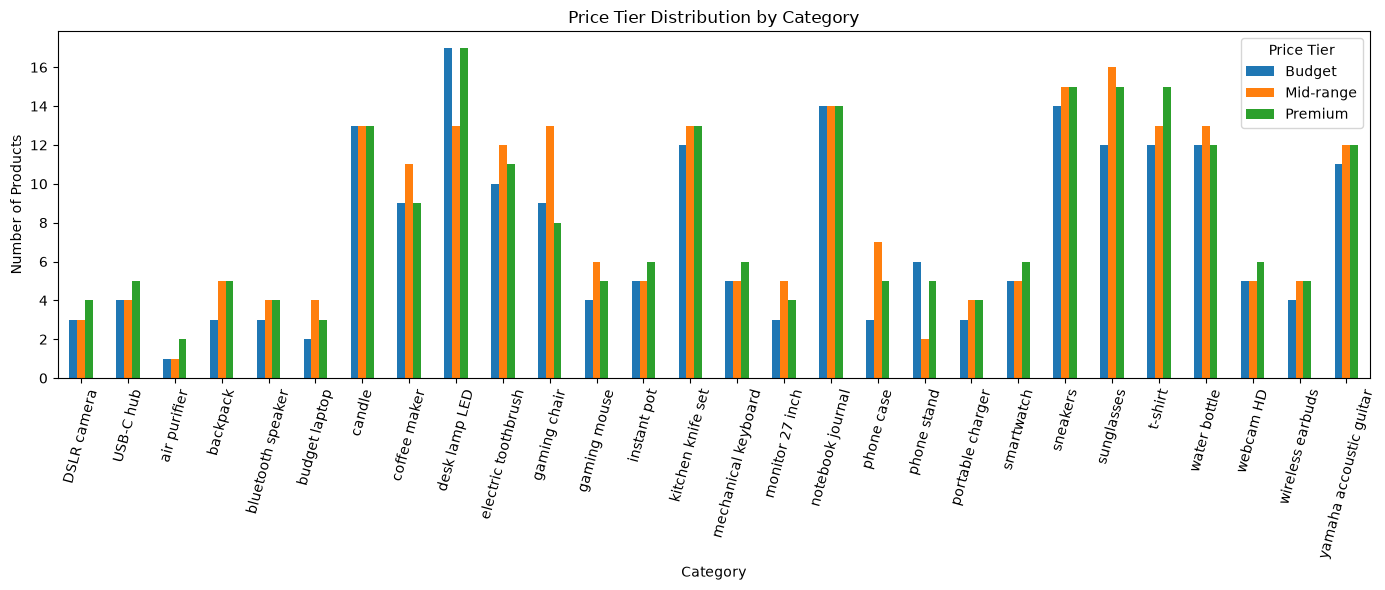

In [50]:
tier_category = pd.crosstab(
    df["category"],
    df["price_tier"]
)

tier_category.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Price Tier Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=75)
plt.legend(title="Price Tier")
plt.tight_layout()
plt.show()

In [51]:
df.groupby("price_tier")["rating"].describe()

,count,mean,std,min,25%,50%,75%,max
price_tier,,,,,,,,
Budget,204.0,4.481863,0.244172,3.7,4.375,4.5,4.6,5.0
Mid-range,228.0,4.494737,0.231769,3.7,4.400,4.5,4.6,5.0
Premium,229.0,4.499563,0.211407,3.7,4.400,4.5,4.6,5.0


In [52]:
df.groupby("price_tier")["ratingCount"].describe()

,count,mean,std,min,25%,50%,75%,max
price_tier,,,,,,,,
Budget,204.0,8525.583333,17207.872380,1.0,462.00,2290.0,7244.5,117120.0
Mid-range,228.0,13246.671053,31609.605888,1.0,606.75,2412.5,9202.0,204745.0
Premium,229.0,12813.445415,38155.808216,1.0,552.00,1785.0,8294.0,334730.0


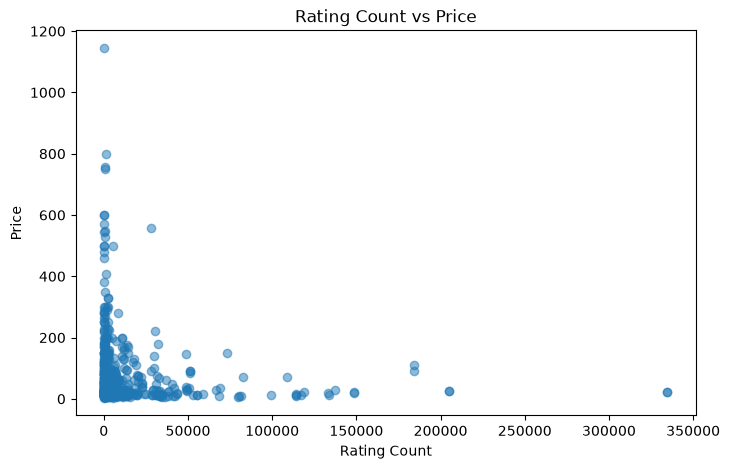

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["ratingCount"],
    df["price"],
    alpha=0.5
)

plt.xlabel("Rating Count")
plt.ylabel("Price")
plt.title("Rating Count vs Price")
plt.show()

In [54]:
tier_percentage = pd.crosstab(
    df["category"],
    df["price_tier"],
    normalize="index"
) * 100

print(tier_percentage.round(2))

price_tier               Budget  Mid-range  Premium
category                                           
DSLR camera               30.00      30.00    40.00
USB-C hub                 30.77      30.77    38.46
air purifier              25.00      25.00    50.00
backpack                  23.08      38.46    38.46
bluetooth speaker         27.27      36.36    36.36
budget laptop             22.22      44.44    33.33
candle                    33.33      33.33    33.33
coffee maker              31.03      37.93    31.03
desk lamp LED             36.17      27.66    36.17
electric toothbrush       30.30      36.36    33.33
gaming chair              30.00      43.33    26.67
gaming mouse              26.67      40.00    33.33
instant pot               31.25      31.25    37.50
kitchen knife set         31.58      34.21    34.21
mechanical keyboard       31.25      31.25    37.50
monitor 27 inch           25.00      41.67    33.33
notebook journal          33.33      33.33    33.33
phone case  

In [57]:
from sklearn.model_selection import train_test_split

X = df[
    [
        "title",
        "description",
        "brand",
        "category",
        "rating",
        "ratingCount"
    ]
].copy()

y = df["price_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 528
Testing samples: 133


In [58]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# Text features
title_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=3000
    ))
])

description_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=3000
    ))
])

# Categorical features
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Rating
rating_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Rating count
rating_count_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("title", title_pipe, "title"),
    ("description", description_pipe, "description"),
    ("categorical", categorical_pipe, ["brand", "category"]),
    ("rating", rating_pipe, ["rating"]),
    ("ratingCount", rating_count_pipe, ["ratingCount"])
])

In [61]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [64]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [65]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Budget", "Mid-range", "Premium"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5113
Macro F1: 0.5113

Classification Report:
              precision    recall  f1-score   support

      Budget       0.49      0.56      0.52        41
   Mid-range       0.54      0.48      0.51        46
     Premium       0.51      0.50      0.51        46

    accuracy                           0.51       133
   macro avg       0.51      0.51      0.51       133
weighted avg       0.51      0.51      0.51       133


Confusion Matrix:
[[23  7 11]
 [13 22 11]
 [11 12 23]]


In [68]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        max_iter=10000,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Accuracy:",
      round(accuracy_score(y_test, svm_pred), 4))

print("Linear SVM Macro F1:",
      round(f1_score(y_test, svm_pred, average="macro"), 4))

Linear SVM Accuracy: 0.5564
Linear SVM Macro F1: 0.5559


In [69]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV Macro F1:", grid_search.best_score_)

Best C: {'classifier__C': 10}
Best CV Macro F1: 0.5284621089038862


In [70]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned SVM Accuracy:",
      round(accuracy_score(y_test, y_pred_tuned), 4))

print("Tuned SVM Macro F1:",
      round(f1_score(y_test, y_pred_tuned, average="macro"), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Budget", "Mid-range", "Premium"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned SVM Accuracy: 0.5639
Tuned SVM Macro F1: 0.564

Classification Report:
              precision    recall  f1-score   support

      Budget       0.58      0.68      0.63        41
   Mid-range       0.52      0.50      0.51        46
     Premium       0.59      0.52      0.55        46

    accuracy                           0.56       133
   macro avg       0.56      0.57      0.56       133
weighted avg       0.56      0.56      0.56       133


Confusion Matrix:
[[28  7  6]
 [12 23 11]
 [ 8 14 24]]


In [72]:
best_model = grid_search.best_estimator_
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Get feature names from each transformer
title_features = (
    preprocessor_fitted
    .named_transformers_["title"]
    .get_feature_names_out()
)

description_features = (
    preprocessor_fitted
    .named_transformers_["description"]
    .get_feature_names_out()
)

categorical_features = (
    preprocessor_fitted
    .named_transformers_["categorical"]
    .get_feature_names_out(
        ["brand", "category"]
    )
)

# Numerical features have known names
numeric_features = [
    "rating",
    "ratingCount"
]

# Combine all feature names
feature_names = np.concatenate([
    ["title_" + f for f in title_features],
    ["description_" + f for f in description_features],
    categorical_features,
    numeric_features
])

classifier = best_model.named_steps["classifier"]

print("Number of features:", len(feature_names))
print("Coefficient shape:", classifier.coef_.shape)

Number of features: 6259
Coefficient shape: (3, 6259)


In [76]:
from sentence_transformers import SentenceTransformer

print("sentence-transformers installed successfully")

d:\Rafi\BJIT\Amazon Scrapper\Project\AmazonScrapper\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sentence-transformers installed successfully


In [77]:
model_name = "all-MiniLM-L6-v2"

In [78]:
product_text = (
    df["title"].fillna("") + ". " +
    df["description"].fillna("")
)

print(product_text.head())

0    Wireless Earbuds, Bluetooth 5.3 Headphones HiF...
1    Wireless Earbuds, Bluetooth 5.3 Headphones HiF...
2    XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 ...
3    Wireless Earbuds Bluetooth Headphones, 54H Pla...
4    HAOYUYAN Wireless Earbuds, Sports Bluetooth He...
dtype: str


In [79]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded.")

d:\Rafi\BJIT\Amazon Scrapper\Project\AmazonScrapper\.venv-1\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ACER\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 826.69it/s]


Embedding model loaded.


In [82]:
df = df.reset_index(drop=True)

product_text = (
    df["title"].fillna("") + ". " +
    df["description"].fillna("")
)

embeddings = embedding_model.encode(
    product_text.tolist(),
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

Batches: 100%|██████████| 21/21 [00:29<00:00,  1.40s/it]

Embedding shape: (661, 384)


In [84]:
X = df[
    [
        "title",
        "description",
        "brand",
        "category",
        "rating",
        "ratingCount"
    ]
].copy()

y = df["price_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_embeddings = embeddings[X_train.index]
X_test_embeddings = embeddings[X_test.index]

y_train_embeddings = y.loc[X_train.index]
y_test_embeddings = y.loc[X_test.index]

print("Train:", X_train_embeddings.shape)
print("Test:", X_test_embeddings.shape)

Train: (528, 384)
Test: (133, 384)


In [85]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")

X_cat = cat_imputer.fit_transform(
    df[["brand", "category"]]
)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_cat = encoder.fit_transform(X_cat)

print("Categorical features:", X_cat.shape)

Categorical features: (661, 299)


In [86]:
from sklearn.preprocessing import StandardScaler

X_num = df[["rating", "ratingCount"]].copy()

X_num["ratingCount"] = np.log1p(X_num["ratingCount"])

num_imputer = SimpleImputer(strategy="median")
X_num = num_imputer.fit_transform(X_num)

scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

print("Numerical features:", X_num.shape)

Numerical features: (661, 2)


In [87]:
from scipy.sparse import hstack, csr_matrix

# Combine all features
X_all = np.hstack([
    embeddings,
    X_cat,
    X_num
])

print("Combined feature shape:", X_all.shape)

Combined feature shape: (661, 685)


In [88]:
X_train_final = X_all[X_train.index]
X_test_final = X_all[X_test.index]

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

Training shape: (528, 685)
Testing shape: (133, 685)


In [89]:
from sklearn.linear_model import LogisticRegression

embedding_classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)

embedding_classifier.fit(
    X_train_embeddings,
    y_train_embeddings
)

embedding_pred = embedding_classifier.predict(
    X_test_embeddings
)

print(
    "Embedding + Logistic Regression Accuracy:",
    round(accuracy_score(y_test_embeddings, embedding_pred), 4)
)

print(
    "Embedding + Logistic Regression Macro F1:",
    round(
        f1_score(
            y_test_embeddings,
            embedding_pred,
            average="macro"
        ),
        4
    )
)

Embedding + Logistic Regression Accuracy: 0.4286
Embedding + Logistic Regression Macro F1: 0.428


In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Categorical preprocessing
cat_imputer_rf = SimpleImputer(strategy="most_frequent")

X_train_cat = cat_imputer_rf.fit_transform(
    X_train[["brand", "category"]]
)

X_test_cat = cat_imputer_rf.transform(
    X_test[["brand", "category"]]
)

encoder_rf = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder_rf.fit_transform(X_train_cat)
X_test_cat = encoder_rf.transform(X_test_cat)

# Numerical features
X_train_num = X_train[["rating", "ratingCount"]].copy()
X_test_num = X_test[["rating", "ratingCount"]].copy()

# Log-transform rating count
X_train_num["ratingCount"] = np.log1p(
    X_train_num["ratingCount"]
)
X_test_num["ratingCount"] = np.log1p(
    X_test_num["ratingCount"]
)

# Combine
X_train_rf = np.hstack([
    X_train_cat,
    X_train_num
])

X_test_rf = np.hstack([
    X_test_cat,
    X_test_num
])

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)

rf_pred = rf_model.predict(X_test_rf)

print(
    "Random Forest Accuracy:",
    round(accuracy_score(y_test, rf_pred), 4)
)

print(
    "Random Forest Macro F1:",
    round(f1_score(y_test, rf_pred, average="macro"), 4)
)

Random Forest Accuracy: 0.4586
Random Forest Macro F1: 0.4528


In [91]:
best_model = grid_search.best_estimator_

classifier = best_model.named_steps["classifier"]
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Get feature names from each part
title_features = (
    preprocessor_fitted
    .named_transformers_["title"]
    .get_feature_names_out()
)

description_features = (
    preprocessor_fitted
    .named_transformers_["description"]
    .get_feature_names_out()
)

categorical_features = (
    preprocessor_fitted
    .named_transformers_["categorical"]
    .get_feature_names_out(
        ["brand", "category"]
    )
)

feature_names = np.concatenate([
    ["title_" + f for f in title_features],
    ["description_" + f for f in description_features],
    categorical_features,
    ["rating", "ratingCount"]
])

# Top 10 features for each class
for i, class_name in enumerate(classifier.classes_):

    coefficients = classifier.coef_[i]

    top_indices = np.argsort(
        coefficients
    )[-10:][::-1]

    print(f"\nTop features for {class_name}:")

    for idx in top_indices:
        print(
            f"{feature_names[idx]}: "
            f"{coefficients[idx]:.4f}"
        )


Top features for Budget:
title_vanilla: 1.2259
title_girls: 1.0845
brand_RJYWGS: 1.0725
title_women short: 1.0476
title_g2000: 1.0315
title_g2000 multipack: 1.0315
brand_FAGUMA: 1.0059
brand_Amorston: 0.9907
brand_ZCZN: 0.9857
title_mini: 0.9761

Top features for Mid-range:
title_gray: 2.9914
title_frame retro: 1.3722
title_g5000: 1.3523
title_sunglasses men: 1.2908
brand_SOJOS: 1.2352
brand_FOCUS DAY: 1.0665
title_men polarized: 1.0589
title_retro: 1.0313
title_foam: 1.0285
brand_Under Armour: 1.0246

Top features for Premium:
title_frame driving: 1.4265
title_soft: 1.0743
title_edelman women: 1.0618
title_edelman: 1.0618
brand_Vangoa: 1.0509
title_basic tees: 0.9300
title_shirts short: 0.9300
title_tees: 0.9292
brand_ASICS: 0.9103
description_round: 0.8902


In [92]:
i = list(classifier.classes_).index("Premium")

coefficients = classifier.coef_[i]

top_indices = np.argsort(
    coefficients
)[-10:][::-1]

print("Top features for Premium:")

for idx in top_indices:
    print(
        f"{feature_names[idx]}: "
        f"{coefficients[idx]:.4f}"
    )

Top features for Premium:
title_frame driving: 1.4265
title_soft: 1.0743
title_edelman women: 1.0618
title_edelman: 1.0618
brand_Vangoa: 1.0509
title_basic tees: 0.9300
title_shirts short: 0.9300
title_tees: 0.9292
brand_ASICS: 0.9103
description_round: 0.8902


In [94]:
import joblib

joblib.dump(
    best_model,
    "data/price_tier_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
